<a href="https://colab.research.google.com/github/wujh03/MSSP6070/blob/main/Assignments/0930case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Academic Performance Case Study
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
url = "https://raw.githubusercontent.com/wujh03/MSSP6070/main/data/academic_performance.csv"

df = pd.read_csv(url)
## Data Inspection
df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [5]:
df.shape

(12411, 45)

The dataset contains 12411 observations and 45 variables.

In [11]:
## Global Performance by Gender
df["GENDER"].value_counts()
#Group by gender and calculate the number of people, mean, median and standard deviation of the Global Score in each group.
gender_summary = df.groupby("GENDER")["G_SC"].agg(
    ["count", "mean", "median", "std"]
)
gender_summary


,count,mean,median,std
GENDER,,,,
F,5043,161.278207,162.0,22.332939
M,7368,163.690825,164.0,23.582616


In [14]:
gender_means = df.groupby("GENDER")["G_SC"].mean()
gender_means

,G_SC
GENDER,
F,161.278207
M,163.690825


In [15]:
gender_difference = gender_means["M"] - gender_means["F"]
gender_difference

np.float64(2.4126177737903447)

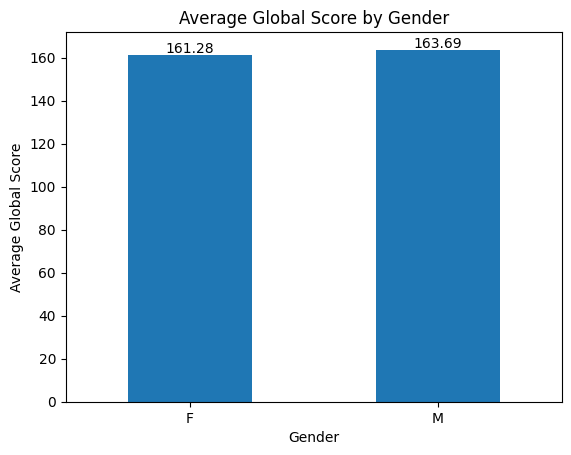

In [19]:
ax = gender_means.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Average Global Score")
plt.title("Average Global Score by Gender")
plt.xticks(rotation=0)

for i, value in enumerate(gender_means):
    ax.text(i, value + 1, f"{value:.2f}", ha="center")

plt.show()

In [31]:
## Global Performance by Socioeconomic Stratum
df["STRATUM"].value_counts(dropna=False)
stratum_data = df[df["STRATUM"] != "0"]
stratum_summary = stratum_data.groupby("STRATUM")["G_SC"].agg(
    ["count", "mean", "median", "std"]
)

stratum_summary

,count,mean,median,std
STRATUM,,,,
Stratum 1,1709,152.352838,152.0,21.937401
Stratum 2,4029,158.199305,158.0,22.278029
Stratum 3,4045,163.815328,164.0,21.693970
Stratum 4,1578,172.002535,174.0,21.469094
Stratum 5,633,177.387046,179.0,21.543236
Stratum 6,403,181.511166,184.0,21.879401


In [32]:
stratum_order = [
    "Stratum 1",
    "Stratum 2",
    "Stratum 3",
    "Stratum 4",
    "Stratum 5",
    "Stratum 6"
]

stratum_means = (
    stratum_data
    .groupby("STRATUM")["G_SC"]
    .mean()
    .reindex(stratum_order)
)

stratum_means

,G_SC
STRATUM,
Stratum 1,152.352838
Stratum 2,158.199305
Stratum 3,163.815328
Stratum 4,172.002535
Stratum 5,177.387046
Stratum 6,181.511166


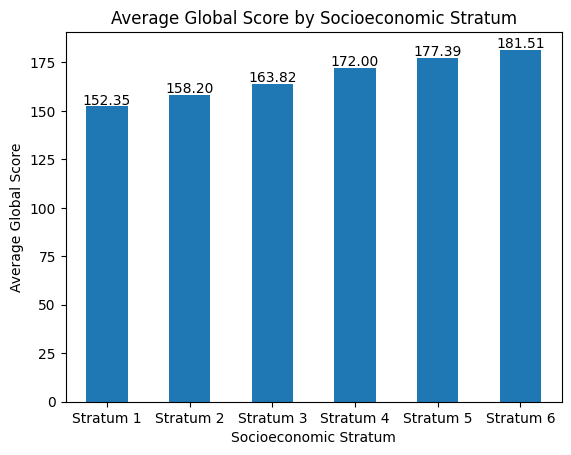

In [33]:
ax = stratum_means.plot(kind="bar")

plt.xlabel("Socioeconomic Stratum")
plt.ylabel("Average Global Score")
plt.title("Average Global Score by Socioeconomic Stratum")
plt.xticks(rotation=0)

for i, value in enumerate(stratum_means):
    ax.text(i, value + 1, f"{value:.2f}", ha="center")

plt.show()

In [34]:
stratum_difference = (
    stratum_means["Stratum 6"]
    - stratum_means["Stratum 1"]
)

stratum_difference

np.float64(29.15832833619126)

In [45]:
## Parental Education and Global Performance
df["EDU_FATHER"] = df["EDU_FATHER"].str.strip()
df["EDU_MOTHER"] = df["EDU_MOTHER"].str.strip()
df["EDU_FATHER"].value_counts(dropna=False)

,count
EDU_FATHER,
Complete professional education,3016
Complete Secundary,2843
Complete technique or technology,1194
Incomplete Secundary,1091
Postgraduate education,1085
Complete primary,824
Incomplete primary,735
Incomplete Professional Education,425
Not sure,407


In [46]:
df["EDU_MOTHER"].value_counts(dropna=False)

,count
EDU_MOTHER,
Complete Secundary,3106
Complete professional education,3059
Complete technique or technology,1495
Incomplete Secundary,1056
Postgraduate education,997
Complete primary,713
Incomplete primary,541
Incomplete Professional Education,502
0,388


In [48]:
education_order = [
    "Ninguno",
    "Incomplete primary",
    "Complete primary",
    "Incomplete Secundary",
    "Complete Secundary",
    "Incomplete technical or technological",
    "Complete technique or technology",
    "Incomplete Professional Education",
    "Complete professional education",
    "Postgraduate education"
]

In [49]:
father_means = (
    df[df["EDU_FATHER"].isin(education_order)]
    .groupby("EDU_FATHER")["G_SC"]
    .mean()
    .reindex(education_order)
)

father_means

,G_SC
EDU_FATHER,
Ninguno,156.634146
Incomplete primary,155.729252
Complete primary,155.195388
Incomplete Secundary,156.535289
Complete Secundary,158.785790
Incomplete technical or technological,162.101083
Complete technique or technology,164.033501
Incomplete Professional Education,166.917647
Complete professional education,167.765915


In [50]:
mother_means = (
    df[df["EDU_MOTHER"].isin(education_order)]
    .groupby("EDU_MOTHER")["G_SC"]
    .mean()
    .reindex(education_order)
)

mother_means

,G_SC
EDU_MOTHER,
Ninguno,149.705882
Incomplete primary,154.853974
Complete primary,155.336606
Incomplete Secundary,155.672348
Complete Secundary,158.470702
Incomplete technical or technological,161.879765
Complete technique or technology,163.242140
Incomplete Professional Education,166.685259
Complete professional education,168.845374


In [51]:
father_summary = df.groupby("EDU_FATHER")["G_SC"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean")

father_summary

,count,mean,median,std
EDU_FATHER,,,,
0,391,155.076726,155.0,20.057207
Complete primary,824,155.195388,155.0,22.410767
Incomplete primary,735,155.729252,156.0,20.942412
Incomplete Secundary,1091,156.535289,157.0,21.736989
Ninguno,123,156.634146,159.0,23.188560
Complete Secundary,2843,158.785790,159.0,22.114288
Not sure,407,160.294840,159.0,22.939555
Incomplete technical or technological,277,162.101083,162.0,21.881198
Complete technique or technology,1194,164.033501,164.0,22.165359


In [52]:
mother_summary = df.groupby("EDU_MOTHER")["G_SC"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean")

mother_summary

,count,mean,median,std
EDU_MOTHER,,,,
Ninguno,34,149.705882,152.5,27.930139
Incomplete primary,541,154.853974,155.0,21.636024
0,388,154.930412,155.0,19.954154
Complete primary,713,155.336606,155.0,22.012293
Incomplete Secundary,1056,155.672348,156.0,21.928635
Complete Secundary,3106,158.470702,159.0,21.949597
Not sure,179,159.407821,159.0,25.469659
Incomplete technical or technological,341,161.879765,164.0,20.744388
Complete technique or technology,1495,163.242140,163.0,21.943495


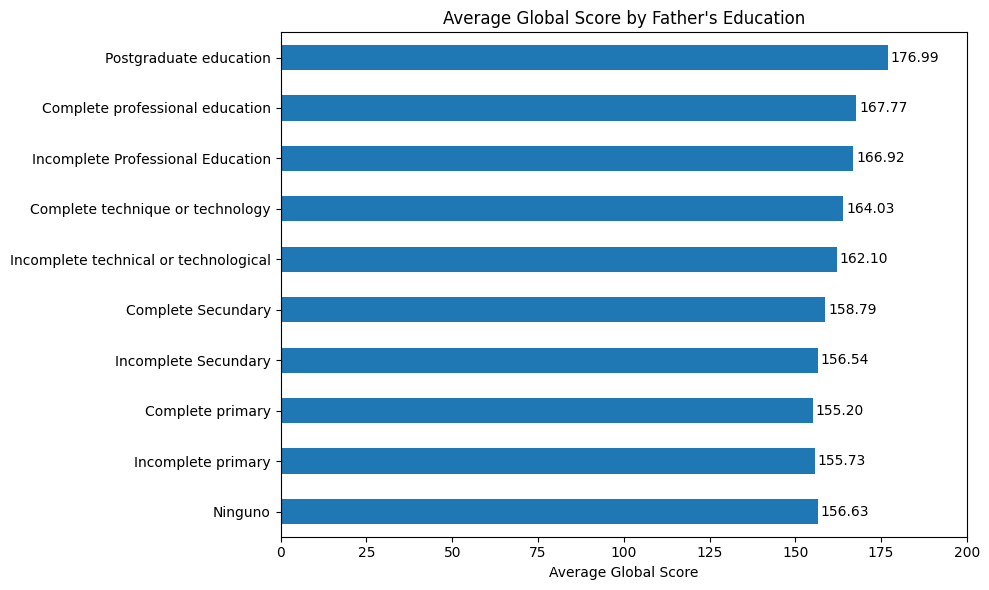

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

father_means.plot(kind="barh", ax=ax)

ax.set_xlabel("Average Global Score")
ax.set_ylabel("")
ax.set_title("Average Global Score by Father's Education")

# Leave more space on the right for value labels
ax.set_xlim(0, 200)

# Add score labels
for i, value in enumerate(father_means):
    ax.text(value + 0.8, i, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()